# Lab 6 — GAN для предсказания траекторий

- **Генератор** `G`: из растра сцены → будущая траектория 50×2;
- **Дискриминатор** `D`: история + траектория → real/fake;
- **Функция потерь генератора:** adversarial (обман D) + L1-регуляризация (стабилизирует GAN).

In [1]:
import os                          
import json                        
import matplotlib.pyplot as plt   
import numpy as np        

from pathlib import Path      

# --- PyTorch ---
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision.models import resnet18

# --- l5kit: данные, датасет, растеризация ---
from l5kit.data import ChunkedDataset, LocalDataManager
from l5kit.dataset import AgentDataset
from l5kit.rasterization import build_rasterizer

# --- l5kit: геометрия и отрисовка траекторий ---
from l5kit.geometry import transform_points
from l5kit.visualization import (PREDICTED_POINTS_COLOR, TARGET_POINTS_COLOR, draw_trajectory)

c:\Users\sadovets\Dev\BMSTU\IU1_ML\sem2\lab6\.venv\lib\site-packages\l5kit\dataset\select_agents.py:31: UserWarning: Windows detected. BLOSC_NOLOCK has not been set as it causes memory leaks on Windows.However, writing the mask with this config may be inconsistent.
  warnings.warn(


## 1. AgentDataset + PyTorch DataLoader

- `LocalDataManager` + `ChunkedDataset` — открытие `sample.zarr`;
- `build_rasterizer(cfg, dm)` — растеризатор по собранной конфигурации (`box_debug` — без карты);
- `AgentDataset(cfg, zarr, rasterizer)` — PyTorch-датасет: один элемент = один агент
  в один момент времени (растр + история + будущее);
- `DataLoader` — стандартный PyTorch: батчи, перемешивание.

In [30]:
DATA_ROOT = Path("../data/raw").resolve()
FULL_DATA_ROOT = Path("D:/ML_datasets/lyft_data")

FULL_FILES = [
    "train.zarr.zip",
    "validate.zarr.zip",   
    "test.zarr.zip",       
]

if not DATA_ROOT.exists():
    DATA_ROOT = Path("data/raw").resolve()
assert (DATA_ROOT / "sample.zarr").exists(), f"Не найден sample.zarr в {DATA_ROOT}"

print("DATA_ROOT: ", DATA_ROOT)

os.environ["L5KIT_DATA_FOLDER"] = str(DATA_ROOT)

cfg = {
    "raster_params": {
        "raster_size": [224, 224], 
        "pixel_size": [0.5, 0.5],      
        "ego_center": [0.25, 0.5],  
        "map_type": "box_debug",        
        "filter_agents_threshold": 0.5, 
        "set_origin_to_bottom": False,
        "disable_traffic_light_faces": False,
        "dataset_meta_key": "meta.json",
    },
    "model_params": {
        "history_num_frames": 10, 
        "history_num_frames_ego": 10,
        "history_num_frames_agents": 10,
        "history_step_size": 1,
        "history_delta_time": 0.1,
        "future_num_frames": 50,
        "future_step_size": 1,
        "future_delta_time": 0.1,
        "step_time": 0.1,
        "render_ego_history": False,
    },
}

dm = LocalDataManager(None)
zarr_dataset = ChunkedDataset(dm.require("sample.zarr")).open()
rasterizer = build_rasterizer(cfg, dm)
agent_dataset = AgentDataset(cfg, zarr_dataset, rasterizer)
print(f"Примеров: {len(agent_dataset)}")

DATA_ROOT:  C:\Users\sadovets\Dev\BMSTU\IU1_ML\sem2\lab6\data\raw
Примеров: 111634


In [3]:
BATCH_SIZE = 12

# DataLoader — итератор поверх датасета.
# Каждый раз, когда из него просят следующий элемент (next() или for batch in loader),
# он берёт BATCH_SIZE случайных примеров из agent_dataset,
# склеивает их по первой оси в батч и отдаёт словарь тензоров.

loader = DataLoader(agent_dataset, batch_size=BATCH_SIZE, shuffle=True) # num_workers=0

# iter(loader) — итератор, next(...) — взять ОДИН батч и посмотреть, что внутри.
batch = next(iter(loader))

for k, v in batch.items():
    if hasattr(v, "shape"):
        print(f"{k:28s} {str(tuple(v.shape)):20s} {v.dtype}")

frame_index                  (12,)                torch.int64
image                        (12, 22, 224, 224)   torch.float32
target_positions             (12, 50, 2)          torch.float32
target_yaws                  (12, 50, 1)          torch.float32
target_velocities            (12, 50, 2)          torch.float32
target_availabilities        (12, 50)             torch.float32
history_positions            (12, 11, 2)          torch.float32
history_yaws                 (12, 11, 1)          torch.float32
history_velocities           (12, 10, 2)          torch.float32
history_availabilities       (12, 11)             torch.float32
world_to_image               (12, 3, 3)           torch.float64
raster_from_agent            (12, 3, 3)           torch.float64
raster_from_world            (12, 3, 3)           torch.float64
agent_from_world             (12, 3, 3)           torch.float64
world_from_agent             (12, 3, 3)           torch.float64
centroid                     (12, 2)      

- `image` — растр сцены: `(BATCH_SIZE, 22, 224, 224)` — 11 кадров (история + текущий) × 2 канала
  (агенты + эго) для `box_debug`;
- `history_positions` — `(BATCH_SIZE, 11, 2)`, прошлое агента в его системе координат (x, y), м;
- `target_positions` — `(BATCH_SIZE, 50, 2)`, будущее агента;
- `target_availabilities` — `(BATCH_SIZE, 50)`, маска валидных точек будущего.

## 2. Модель

#### Вариант 1

**Generator** - вариационный автоэнкодер (VAE), где: 
- **энкодер** `q(z | история, будущее)`: MLP → мат.среднее, логарифм дисперсии;
- **декодер** `p(будущее | растр изображения, история движения, z)`: лёгкий CNN по растру сцены 224x224 + MLP ([признаки растра + историю + z] → выдаёт 100 чисел = траектория 50×2). При предсказании энкодера нет —> `z ~ N(0, 1)`.

**Функция потерь всей модели** = реконструкция (L1-регуляризация - средняя абсолютная разница, усреднённая по всем точкам) + KL-дивергенция (регуляризует латентное пространство) + adversarial (свой дискриминатор).

VAEGenerator
├── img_enc = ImageEncoder   — «картиночный» энкодер (CNN): растр -> 128 чисел
├── enc/mu/logvar            — «VAE-энкодер» (MLP): история+будущее -> mu, logvar (по 16)
└── dec                      — декодер (MLP): [128 признаков + история + z] -> 50×2

In [5]:
in_channels = batch["image"].shape[1]                 # 22
history_frames = batch["history_positions"].shape[1]  # 11 = 10 истории + текущий кадр

POS_SCALE = 50.0      # нормировка координат: метры -> ~единицы
FUTURE_FRAMES = 50

# print("cuda доступна:", torch.cuda.is_available())
# print("версия torch:", torch.__version__, "| cuda в сборке:", torch.version.cuda)
# device = "cuda" if torch.cuda.is_available() else "cpu"
print("RTX 5080 не поддерживается Python 3.8, так что - :(")
device = "cpu"

RTX 5080 не поддерживается Python 3.8, так что - :(


In [ ]:
class ImageEncoder(nn.Module):    
    def __init__(self, in_channels, feat_dim=128):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, 32, 5, 2, 2), 
            nn.ReLU(),           # 224 -> 112
            nn.Conv2d(32, 64, 5, 2, 2), 
            nn.ReLU(),           # 112 -> 56
            nn.Conv2d(64, 128, 5, 2, 2), 
            nn.ReLU(),           # 56 -> 27
            nn.AdaptiveAvgPool2d(1), 
            nn.Flatten(),        # -> 128
        )
        self.fc = nn.Linear(128, feat_dim)

    def forward(self, x):
        return self.fc(self.conv(x))

class VAEGenerator(nn.Module):    
    def __init__(self, in_channels, history_frames, future_frames, z_dim=16, feat_dim=128):
        super().__init__()
        self.z_dim = z_dim
        self.img_enc = ImageEncoder(in_channels, feat_dim)
        
        # энкодер: история + будущее -> mu, logvar для z
        enc_in = (history_frames + future_frames) * 2
        self.enc = nn.Sequential(
                                nn.Linear(enc_in, 256), 
                                nn.ReLU(),
                                nn.Linear(256, 256), 
                                nn.ReLU()
                                )
        self.mu = nn.Linear(256, z_dim)
        self.logvar = nn.Linear(256, z_dim)
        
        # декодер: признаки растра + история + z -> будущее
        dec_in = feat_dim + history_frames * 2 + z_dim
        self.dec = nn.Sequential(
            nn.Linear(dec_in, 256), 
            nn.ReLU(),
            nn.Linear(256, 256), 
            nn.ReLU(),
            nn.Linear(256, future_frames * 2),
        )
        self.future_frames = future_frames

    def encode(self, history, future):
        h = self.enc(torch.cat([history.flatten(1), future.flatten(1)], 1))
        return self.mu(h), self.logvar(h)

    def decode(self, image, history, z):
        x = torch.cat([self.img_enc(image), history.flatten(1), z], 1)
        return self.dec(x).view(-1, self.future_frames, 2)

    def forward(self, image, history, future=None):
        if future is not None:   # режим ОБУЧЕНИЯ: z из энкодера (репараметризация)
            mu, logvar = self.encode(history, future)
            z = mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)
            return self.decode(image, history, z), mu, logvar
        # режим ПРЕДСКАЗАНИЯ: будущего нет -> z ~ N(0, 1)
        z = torch.randn(image.shape[0], self.z_dim, device=image.device)
        return self.decode(image, history, z)

vae = VAEGenerator(in_channels, history_frames, FUTURE_FRAMES).to(device)
print(f"параметров VAE-генератора: {sum(p.numel() for p in vae.parameters()) / 1e6:.1f}M ")

параметров VAE-генератора: 0.5M 


#### Вариант 2

- **Generator**: ResNet-18 без предобучения → линейная голова → 50×2;
- **Discriminator**: склеивает историю и траекторию в один вектор → MLP → real/fake.

In [7]:
try:
    resnet18(weights=None)
    backbone_kwargs = {"weights": None}
except TypeError:
    backbone_kwargs = {"pretrained": False}


class Generator(nn.Module):
    def __init__(self, in_channels: int):
        super().__init__()
        backbone = resnet18(**backbone_kwargs)
        
        # дефолтный conv1 ждёт 3 канала (RGB), у нас 22 (11 кадров x 2) — заменяем
        backbone.conv1 = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.backbone = backbone          # выдаёт вектор признаков размера 1000
        self.head = nn.Linear(1000, FUTURE_FRAMES * 2)  # признаки -> 50 точек (x, y)

    def forward(self, image):
        features = self.backbone(image)
        out = self.head(features)
        return out.view(-1, FUTURE_FRAMES, 2)


class Discriminator(nn.Module):
    def __init__(self, history_frames: int, future_frames: int):
        super().__init__()
        in_dim = (history_frames + future_frames) * 2  # каждая точка = (x, y)
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256), 
            nn.LeakyReLU(0.2),
            nn.Linear(256, 256), 
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
        )

    def forward(self, history, future):
        # flatten(1): (B, T, 2) -> (B, T*2); склеиваем историю и будущее в один вектор
        x = torch.cat([history.flatten(1), future.flatten(1)], dim=1)
        return self.net(x).squeeze(1)


G = Generator(in_channels).to(device)
D = Discriminator(history_frames, FUTURE_FRAMES).to(device)

print(f"device: {device}, каналов растра: {in_channels}, кадров истории: {history_frames}")
print(f"параметров G: {sum(p.numel() for p in G.parameters()) / 1e6:.1f}M, "
      f"D: {sum(p.numel() for p in D.parameters()) / 1e6:.1f}M")

device: cpu, каналов растра: 22, кадров истории: 11
параметров G: 11.8M, D: 0.1M


In [8]:
print("ВХОДЫ/ВЫХОДЫ (на один пример):")
print(f"  G вход:  растр image ({in_channels}, 224, 224) = {in_channels * 224 * 224:,} чисел")
print(f"  G выход: траектория (50, 2) = 100 чисел")
print(f"  D вход:  история (11, 2) + траектория (50, 2) -> вектор из {(11 + 50) * 2} чисел")
print(f"  D выход: 1 число ")

ВХОДЫ/ВЫХОДЫ (на один пример):
  G вход:  растр image (22, 224, 224) = 1,103,872 чисел
  G выход: траектория (50, 2) = 100 чисел
  D вход:  история (11, 2) + траектория (50, 2) -> вектор из 122 чисел
  D выход: 1 число 


## 3. Обучение

1. **Discriminator**: настоящие траектории → 1, сгенерированные → 0;
2. **Generator**: хочет, чтобы D поверил в его траекторию (adversarial loss),
   плюс L1 до ground truth — без него GAN на траекториях быстро расходится.

In [25]:
NUM_STEPS = 80
L1_WEIGHT = 10.0  # во сколько раз L1 важнее adversarial-части

bce = nn.BCEWithLogitsLoss()          # бинарная кросс-энтропия для real/fake
l1 = nn.L1Loss(reduction="none")      # без усреднения: применим маску availabilities сами

MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(exist_ok=True)

In [26]:
torch.manual_seed(42)

D_vae = Discriminator(history_frames, FUTURE_FRAMES).to(device)  # свой дискриминатор
opt_V = torch.optim.Adam(vae.parameters(), lr=1e-4)
opt_Dv = torch.optim.Adam(D_vae.parameters(), lr=1e-4)
KL_WEIGHT = 0.1  # вес KL-члена (beta в терминах beta-VAE)

losses_V, losses_Dv = [], []
it = iter(loader)

for step in range(NUM_STEPS):
    batch = next(it, None)
    if batch is None:
        it = iter(loader)
        batch = next(it)

    image = batch["image"].float().to(device)
    history = batch["history_positions"].float().to(device) / POS_SCALE
    target = batch["target_positions"].float().to(device) / POS_SCALE
    avail = batch["target_availabilities"].float().to(device).unsqueeze(-1)

    # --- шаг дискриминатора: подделка = предсказание со случайным z ---
    with torch.no_grad():
        fake = vae(image, history)
    loss_Dv = 0.5 * (
        bce(D_vae(history, target), torch.ones(BATCH_SIZE, device=device))
        + bce(D_vae(history, fake), torch.zeros(BATCH_SIZE, device=device))
    )
    opt_Dv.zero_grad()
    loss_Dv.backward()
    opt_Dv.step()

    # --- шаг генератора: реконструкция + KL + adversarial ---
    recon, mu, logvar = vae(image, history, target)      # z из энкодера
    recon_loss = (l1(recon, target) * avail).mean()      # L1 по валидным точкам
    kl_loss = (-0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).sum(1)).mean()
    adv_loss = bce(D_vae(history, recon), torch.ones(BATCH_SIZE, device=device))
    loss_V = L1_WEIGHT * recon_loss + KL_WEIGHT * kl_loss + adv_loss
    opt_V.zero_grad()
    loss_V.backward()
    opt_V.step()

    losses_V.append(loss_V.item())
    losses_Dv.append(loss_Dv.item())
    if step % 10 == 0 or step == NUM_STEPS - 1:
        print(f"step {step:3d} | D {loss_Dv.item():.3f} | "
              f"V {loss_V.item():.3f} (recon {recon_loss.item():.3f}, "
              f"kl {kl_loss.item():.3f}, adv {adv_loss.item():.3f})")

# сохраняем — ноутбук 03 сравнит GAN и VAE на одних и тех же примерах
torch.save(vae.state_dict(), MODELS_DIR / "vae_generator.pth")
torch.save(D_vae.state_dict(), MODELS_DIR / "vae_discriminator.pth")
print("VAE-генератор и дискриминатор под него сохранён в models/vae_generator.pth")

step   0 | D 0.693 | V 1.265 (recon 0.060, kl 0.006, adv 0.668)
step  10 | D 0.687 | V 1.274 (recon 0.060, kl 0.008, adv 0.670)
step  20 | D 0.674 | V 1.635 (recon 0.096, kl 0.010, adv 0.675)
step  30 | D 0.686 | V 1.012 (recon 0.033, kl 0.005, adv 0.680)
step  40 | D 0.675 | V 1.179 (recon 0.049, kl 0.006, adv 0.685)
step  50 | D 0.655 | V 1.425 (recon 0.073, kl 0.008, adv 0.691)
step  60 | D 0.683 | V 0.970 (recon 0.028, kl 0.007, adv 0.694)
step  70 | D 0.673 | V 0.992 (recon 0.029, kl 0.007, adv 0.705)
step  79 | D 0.634 | V 1.347 (recon 0.063, kl 0.008, adv 0.713)
VAE-генератор и дискриминатор под него сохранён в models/vae_generator.pth


In [32]:
torch.manual_seed(42)  # для воспроизводимости

opt_G = torch.optim.Adam(G.parameters(), lr=1e-4)
opt_D = torch.optim.Adam(D.parameters(), lr=1e-4)

losses_G, losses_D, losses_adv, losses_l1 = [], [], [], []
it = iter(loader)

for step in range(NUM_STEPS):
    batch = next(it, None)
    if batch is None:        # данные кончились — начинаем проход заново
        it = iter(loader)
        batch = next(it)

    image = batch["image"].float().to(device)
    history = batch["history_positions"].float().to(device) / POS_SCALE
    target = batch["target_positions"].float().to(device) / POS_SCALE
    avail = batch["target_availabilities"].float().to(device).unsqueeze(-1)

    # --- шаг дискриминатора ---
    with torch.no_grad():
        fake = G(image)
    loss_D = 0.5 * (
        bce(D(history, target), torch.ones(BATCH_SIZE, device=device))
        + bce(D(history, fake), torch.zeros(BATCH_SIZE, device=device))
    )
    opt_D.zero_grad()
    loss_D.backward()
    opt_D.step()

    # --- шаг генератора ---
    fake = G(image)
    adv_loss = bce(D(history, fake), torch.ones(BATCH_SIZE, device=device))
    l1_loss = (l1(fake, target) * avail).mean()
    loss_G = adv_loss + L1_WEIGHT * l1_loss
    opt_G.zero_grad()
    loss_G.backward()
    opt_G.step()

    losses_G.append(loss_G.item())
    losses_D.append(loss_D.item())
    losses_adv.append(adv_loss.item())
    losses_l1.append(l1_loss.item())
    if step % 10 == 0 or step == NUM_STEPS - 1:
        print(f"step {step:3d} | D {loss_D.item():.3f} | "
              f"G {loss_G.item():.3f} (adv {adv_loss.item():.3f}, l1 {l1_loss.item():.3f})")
        
        
torch.save(G.state_dict(), MODELS_DIR / "generator.pth")
torch.save(D.state_dict(), MODELS_DIR / "discriminator.pth")

step   0 | D 0.689 | G 1.448 (adv 0.671, l1 0.078)
step  10 | D 0.687 | G 1.392 (adv 0.675, l1 0.072)
step  20 | D 0.663 | G 1.765 (adv 0.684, l1 0.108)
step  30 | D 0.670 | G 1.498 (adv 0.675, l1 0.082)
step  40 | D 0.666 | G 1.322 (adv 0.686, l1 0.064)
step  50 | D 0.652 | G 1.475 (adv 0.690, l1 0.079)
step  60 | D 0.651 | G 1.335 (adv 0.693, l1 0.064)
step  70 | D 0.657 | G 1.235 (adv 0.698, l1 0.054)
step  79 | D 0.641 | G 1.419 (adv 0.700, l1 0.072)


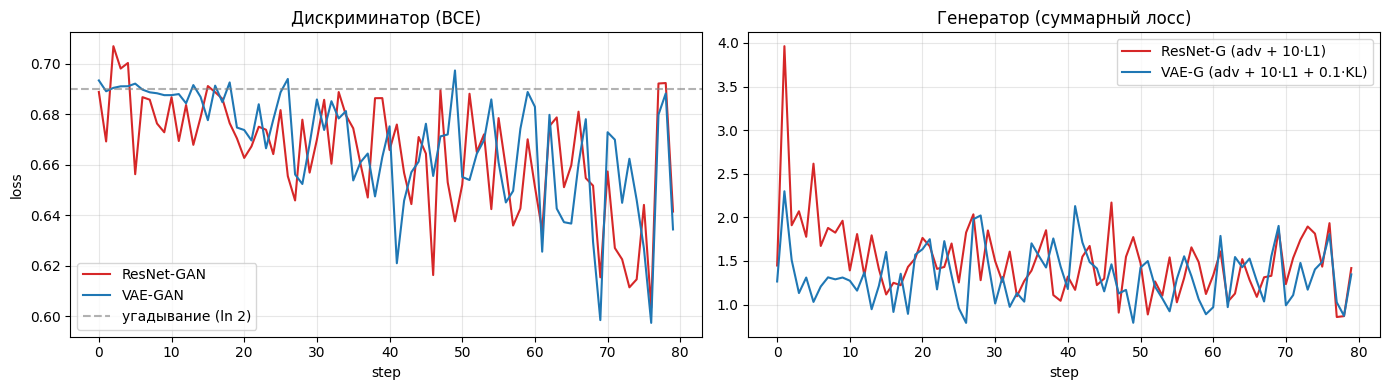

ВАЖНО: лоссы генераторов имеют разный состав (у VAE ещё KL-член),
поэтому их значения между собой напрямую сравнивать нельзя —
честное сравнение только по метрикам ADE/FDE/NLL в ноутбуке 03.


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# картинка 1: BCE дискриминаторов обеих моделей
ax1.plot(losses_D, label="ResNet-GAN", color="tab:red")
ax1.plot(losses_Dv, label="VAE-GAN", color="tab:blue")
ax1.axhline(0.69, ls="--", c="gray", alpha=0.6, label="угадывание (ln 2)")
ax1.set_title("Дискриминатор (BCE)")
ax1.set_xlabel("step")
ax1.set_ylabel("loss")
ax1.legend()
ax1.grid(alpha=0.3)

# картинка 2: суммарные лоссы генераторов
ax2.plot(losses_G, label="ResNet-G (adv + 10·L1)", color="tab:red")
ax2.plot(losses_V, label="VAE-G (adv + 10·L1 + 0.1·KL)", color="tab:blue")
ax2.set_title("Генератор (суммарный лосс)")
ax2.set_xlabel("step")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("ВАЖНО: лоссы генераторов имеют разный состав (у VAE ещё KL-член),")
print("честное сравнение только по метрикам ADE/FDE/NLL в ноутбуке 3")

**Как читать строку `step 20 | D 0.62 | G 4.31 (adv 0.71, l1 0.36)`:**

- `D` — функция потерь дискриминатора (Бинарная кросс-энтропия, BCE). Стартует около **0.69**. Падает → D научился отличать. Если упал почти в 0 — D слишком силён, G перестанет получать полезный сигнал.
- `adv` — насколько G обманывает D (та же шкала, ~0.69 = D не отличает подделку —
- `G` — функция потерь генератора = `adv + l1 · 1e1 `, где
  для генератора это хорошо).
- `l1` — среднее расстояние до настоящей траектории в **нормированных** единицах
  (мы делили координаты на 50 м, так что l1 = 0.36 ≈ 18 м средней ошибки).

## 4. Проверка

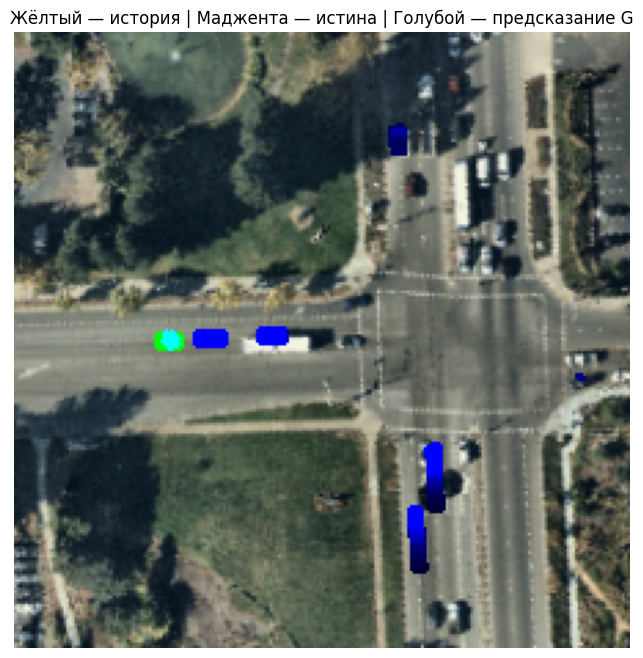

In [ ]:
G.eval()  # режим предсказания

# ищем агента, который за 5 секунд проезжает хотя бы 20 метров —
# иначе история и истина тоже будут точкой (машина просто стоит)
IDX = 1500
for i in range(1500, min(3000, len(agent_dataset))):
    t = agent_dataset[i]["target_positions"]
    if np.linalg.norm(t[-1] - t[0]) > 20:
        IDX = i
        break
print(f"Пример #{IDX}")

# два «вида» одного кадра: box_debug — для ПРЕДСКАЗАНИЯ (на нём обучен G),
# спутник — только для ФОНА
data_model = agent_dataset[IDX]
cfg_sat = {**cfg, "raster_params": {**cfg["raster_params"],
           "map_type": "py_satellite",
           "satellite_map_key": "aerial_map/aerial_map.png",
           "semantic_map_key": "semantic_map/semantic_map.pb"}}
rasterizer_viz = build_rasterizer(cfg_sat, dm)
data_viz = AgentDataset(cfg_sat, zarr_dataset, rasterizer_viz)[IDX]

# предсказание: G выдаёт нормированные координаты -> умножаем обратно на POS_SCALE
image_t = torch.from_numpy(data_model["image"]).unsqueeze(0).float().to(device)
with torch.no_grad():
    pred = G(image_t)[0].cpu().numpy() * POS_SCALE  # (50, 2), метры

# рисуем ТОЛЬКО сырые координаты из data_viz (метры, без всякого POS_SCALE)
bg = rasterizer_viz.to_rgb(data_viz["image"].transpose(1, 2, 0))
m = data_viz["raster_from_agent"]  # матрица метры -> пиксели
draw_trajectory(bg, transform_points(data_viz["history_positions"], m), (255, 255, 0))
draw_trajectory(bg, transform_points(data_viz["target_positions"], m), TARGET_POINTS_COLOR)
draw_trajectory(bg, transform_points(pred, m), PREDICTED_POINTS_COLOR)

plt.figure(figsize=(8, 8))
plt.imshow(bg)
plt.title(f"#{IDX}: жёлтый — история | маджента — истина | голубой — предсказание G")
plt.axis("off")
plt.show()

## 5. Сохранение весов

In [35]:
with open(MODELS_DIR / "cfg.json", "w") as f:
    json.dump(cfg, f, indent=2)

with open(MODELS_DIR / "cfg_sat.json", "w") as f:
    json.dump(cfg, f, indent=2)

for p in sorted(MODELS_DIR.iterdir()):
    print(f"{p.name:20s} {p.stat().st_size / 1e6:.1f} МБ")

cfg.json             0.0 МБ
cfg_sat.json         0.0 МБ
discriminator.pth    0.4 МБ
generator.pth        47.5 МБ
vae_discriminator.pth 0.4 МБ
vae_generator.pth    2.1 МБ
